# Step 1: Load and Inspect the Data

We will first load the dataset into a pandas DataFrame and inspect its structure:
1. **Check data types** to ensure that each column is in the correct format.
2. **Check for any missing values**.
3. **Preview the first few rows** to get a sense of the data.


In [8]:
import pandas as pd

# Load the dataset
df = pd.read_csv("DubaiPropertyForSale.csv")

# Display basic info (data types, non-null counts)
df.info()

# Preview the first few rows to check the data
df.head()

# Check for missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52207 entries, 0 to 52206
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Type        52207 non-null  object
 1   Purpose     52207 non-null  object
 2   Furnishing  52207 non-null  object
 3   Price       52207 non-null  object
 4   Beds        52203 non-null  object
 5   Baths       52199 non-null  object
 6   Area_sqft   52207 non-null  object
 7   Address     52207 non-null  object
dtypes: object(8)
memory usage: 3.2+ MB


Type          0
Purpose       0
Furnishing    0
Price         0
Beds          4
Baths         8
Area_sqft     0
Address       0
dtype: int64

## Checking Raw data

In [9]:
df

,Type,Purpose,Furnishing,Price,Beds,Baths,Area_sqft,Address
0,Apartment,Sale,Unfurnished,"660,000",1 bed,1 bath,729 sqft,"Suburbia Tower 2, Suburbia, Downtown Jebel Ali..."
1,Apartment,Sale,Unfurnished,"2,600,000",2 beds,3 baths,"1,396 sqft","Murjan 5, Murjan, Jumeirah Beach Residence (JB..."
2,Apartment,Sale,Unfurnished,"455,000",Studio,1 bath,569 sqft,"Skycourts Tower B, Skycourts Towers, Dubai Lan..."
3,Apartment,Sale,Unfurnished,"820,000",1 bed,2 baths,835 sqft,"Orion Building, Arjan, Dubai, UAE"
4,Apartment,Sale,Unfurnished,"680,000",Studio,1 bath,314 sqft,"Azizi Riviera 1, Azizi Riviera, Meydan One, Me..."
...,...,...,...,...,...,...,...,...
52202,Apartment,Sale,Unfurnished,"2,020,000",3 beds,4 baths,"1,594 sqft","Azizi Milan 51, Azizi Milan, City of Arabia, D..."
52203,Apartment,Sale,Unfurnished,"2,199,000",1 bed,2 baths,880 sqft,"W Residences, Jumeirah Lake Towers (JLT), Duba..."
52204,Townhouse,Sale,Unfurnished,"13,000,000",4 beds,7 baths,"5,307 sqft","Keturah Reserve, District 7, Mohammed Bin Rash..."
52205,Apartment,Sale,Furnished,"2,950,000",2 beds,3 baths,"1,430 sqft","MBL Royal, JLT Cluster K, Jumeirah Lake Towers..."


In [10]:
# Check all rows where any column has NaN values
df[df.isna().any(axis=1)]

,Type,Purpose,Furnishing,Price,Beds,Baths,Area_sqft,Address
50244,Residential Building,Sale,Unfurnished,"77,000,000",NaN,NaN,"26,910 sqft","OST Tower 10, International City Phase 2 (Wars..."
50245,Residential Floor,Sale,Unfurnished,"22,000,000",NaN,NaN,"9,726 sqft","Hanover Square, JVC District 10, Jumeirah Vill..."
52161,Villa,Sale,Unfurnished,"6,010,204",4 beds,NaN,"4,136 sqft","Alana, The Valley by Emaar, Dubai, UAE"
52162,Villa,Sale,Unfurnished,"14,100,000",5 beds,NaN,6 baths,"Park Gate 2, Dubai Hills Estate, Dubai, UAE"
52163,Apartment,Sale,Unfurnished,"4,627,265",2 beds,NaN,"1,171 sqft","Address Residences Zabeel Tower 1, Address Res..."
52164,Residential Building,Sale,Unfurnished,"77,000,000",NaN,NaN,"26,910 sqft","OST Tower 10, International City Phase 2 (Wars..."
52165,Residential Floor,Sale,Unfurnished,"22,000,000",NaN,NaN,"9,726 sqft","Hanover Square, JVC District 10, Jumeirah Vill..."
52166,Residential Building,Sale,Unfurnished,"16,000,000",10 baths,NaN,"8,121 sqft","Al Salam Building, Liwan 2, Dubai, UAE"


In [11]:
df['Price']

0           660,000
1         2,600,000
2           455,000
3           820,000
4           680,000
            ...    
52202     2,020,000
52203     2,199,000
52204    13,000,000
52205     2,950,000
52206    33,778,000
Name: Price, Length: 52207, dtype: object

## Step 2: Clean the 'Price' Column

The 'Price' column contains values like "1,000,000 AED". We need to:
1. Remove commas and the 'AED' text.
2. Convert the cleaned string to a numeric value (float) to make it usable for modeling.


In [12]:
# Clean 'Price' column: Remove commas, 'AED' and convert to float

def clean_price(price):
    # Remove commas and currency symbols like 'AED'
    price = str(price).replace(",", "").replace("AED", "").strip()
    
    # Convert the cleaned value to float (if it can be converted)
    try:
        return float(price)
    except ValueError:
        return None  # If there's an error (e.g., empty or corrupted value), return NaN

# Apply the cleaning function to the 'Price' column
df['Price_num'] = df['Price'].apply(clean_price)

# Check the cleaned 'Price' column
df[['Price', 'Price_num']].head()  # Display first few rows to verify


,Price,Price_num
0,"660,000",660000.0
1,"2,600,000",2600000.0
2,"455,000",455000.0
3,"820,000",820000.0
4,"680,000",680000.0


In [13]:
df['Price_num'].isnull().sum()  

0

## Step 3: Clean the 'Area_sqft' Column

The 'Area_sqft' column contains values like "1,000 sqft". We need to:
1. Remove the "sqft" text and any commas.
2. Convert the cleaned string to a numeric value (float).


In [14]:
df['Area_sqft']

0          729 sqft
1        1,396 sqft
2          569 sqft
3          835 sqft
4          314 sqft
            ...    
52202    1,594 sqft
52203      880 sqft
52204    5,307 sqft
52205    1,430 sqft
52206    6,755 sqft
Name: Area_sqft, Length: 52207, dtype: object

In [15]:
# Clean 'Area' column: Remove 'sqft' and commas, convert to float

def clean_area(area):
    # Remove commas and 'sqft' text
    area = str(area).replace(",", "").replace("sqft", "").strip()
    
    # Convert the cleaned value to float (if possible)
    try:
        return float(area)
    except ValueError:
        return None  # Return None if the conversion fails

# Apply the cleaning function to the 'Area_sqft' column
df['Area_num'] = df['Area_sqft'].apply(clean_area)

# Check the cleaned 'Area' column
df[['Area_sqft', 'Area_num']].head()  # Display first few rows to verify


,Area_sqft,Area_num
0,729 sqft,729.0
1,"1,396 sqft",1396.0
2,569 sqft,569.0
3,835 sqft,835.0
4,314 sqft,314.0


In [16]:
df['Area_num'].isnull().sum()

1

## Handle Missing Values in Area_num

In [17]:
# Fill missing values in Area_num with the median (or you can choose mean or mode based on your data)
df['Area_num'].fillna(df['Area_num'].median(), inplace=True)

# Verify that no missing values remain in Area_num
print(df['Area_num'].isnull().sum())


0


## Step 4: Clean the 'Beds' Column

The 'Beds' column contains values like "1 bed", "Studio", or "2 beds". We'll clean it by:
1. Converting "Studio" to 0.
2. Extracting the numeric part for other entries, converting them to numeric values.


In [18]:
df['Beds']

0         1 bed
1        2 beds
2        Studio
3         1 bed
4        Studio
          ...  
52202    3 beds
52203     1 bed
52204    4 beds
52205    2 beds
52206    5 beds
Name: Beds, Length: 52207, dtype: object

In [19]:
# Clean 'Beds' column: Convert 'Studio' to 0, and extract numeric values

def clean_beds(beds):
    # If the value is "Studio", assign 0 beds
    if 'studio' in str(beds).lower():
        return 0
    # Otherwise, extract the first numeric part of the string (e.g. "2 beds" -> 2)
    match = pd.to_numeric(str(beds).split()[0], errors='coerce')
    return match

# Apply the cleaning function to the 'Beds' column
df['Beds_num'] = df['Beds'].apply(clean_beds)

# Check the cleaned 'Beds' column
df[['Beds', 'Beds_num']].head()  # Display first few rows to verify


,Beds,Beds_num
0,1 bed,1.0
1,2 beds,2.0
2,Studio,0.0
3,1 bed,1.0
4,Studio,0.0


In [20]:
df['Beds_num'].unique()

array([ 1.,  2.,  0.,  3.,  4.,  5.,  7.,  6.,  8., 11.,  9., 10., nan])

## Step 5: Clean the 'Baths' Column

The 'Baths' column contains values like "1 bath", "2 baths", etc. We'll clean it by:
1. Extracting the numeric value (i.e., the first number in the string).
2. Converting the extracted value into a numeric format.


In [21]:
df['Baths']

0         1 bath
1        3 baths
2         1 bath
3        2 baths
4         1 bath
          ...   
52202    4 baths
52203    2 baths
52204    7 baths
52205    3 baths
52206    6 baths
Name: Baths, Length: 52207, dtype: object

In [22]:
# Clean 'Baths' column: Extract numeric values

def clean_baths(baths):
    # Extract the first numeric value (in case of "1 bath", "2 baths")
    match = pd.to_numeric(str(baths).split()[0], errors='coerce')
    return match

# Apply the cleaning function to the 'Baths' column
df['Baths_num'] = df['Baths'].apply(clean_baths)

# Check the cleaned 'Baths' column
df[['Baths', 'Baths_num']].head()  # Display first few rows to verify


,Baths,Baths_num
0,1 bath,1.0
1,3 baths,3.0
2,1 bath,1.0
3,2 baths,2.0
4,1 bath,1.0


In [23]:
df['Baths_num'].unique()

array([ 1.,  3.,  2.,  5.,  6.,  4.,  8.,  7.,  9., 11., 10., nan])

## Step 6: Handle Missing Values in Beds_num and Baths_num

In [24]:
# Fill missing values with the mode or median (you can choose the method based on the column's distribution)
df['Beds_num'].fillna(df['Beds_num'].mode()[0], inplace=True)  # Filling missing values with mode for Beds
df['Baths_num'].fillna(df['Baths_num'].mode()[0], inplace=True)  # Filling missing values with mode for Baths

# Verify that no missing values remain
print(df[['Beds_num', 'Baths_num']].isnull().sum())


Beds_num     0
Baths_num    0
dtype: int64


## Step 7: Validate Categorical Columns (Check Uniqueness)

In [25]:
# Check unique values in categorical columns
print(df['Type'].unique())
print(df['Purpose'].unique())
print(df['Furnishing'].unique())


['Apartment' 'Villa' 'Townhouse' 'Penthouse' 'Residential Floor'
 'Hotel Apartment' 'Residential Building' 'Villa Compound']
['Sale']
['Unfurnished' 'Furnished']


In [26]:
# Convert categorical variables into numeric (Label Encoding)
df['Type'] = df['Type'].astype('category').cat.codes
df['Purpose'] = df['Purpose'].astype('category').cat.codes
df['Furnishing'] = df['Furnishing'].astype('category').cat.codes


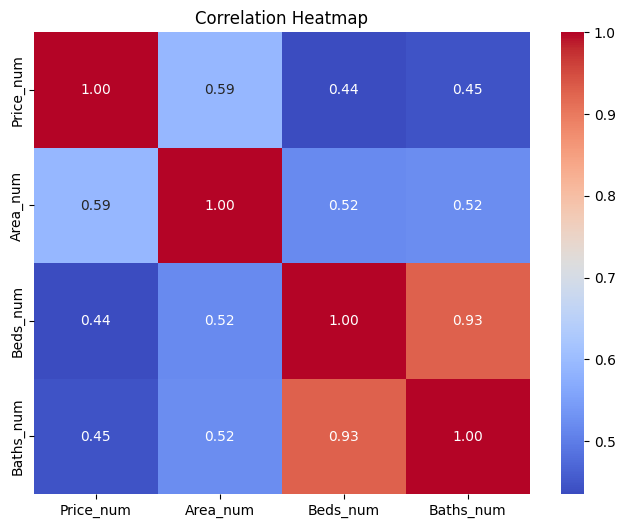

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting correlation heatmap
correlation = df[['Price_num', 'Area_num', 'Beds_num', 'Baths_num']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


## Step 8: Convert Price_num to a More Suitable Format

In [28]:
# Check if any values in Price_num are too high
price_outliers = df[df['Price_num'] > 50000000]  # Check for values over 50 million AED
print(price_outliers[['Price_num', 'Area_sqft', 'Type']])  # Display high prices and corresponding columns


         Price_num    Area_sqft  Type
51      60000000.0  18,833 sqft     6
440     65000000.0  11,452 sqft     6
632    160000000.0  42,111 sqft     3
719     66203000.0   9,465 sqft     0
1257    90000000.0   2,960 sqft     2
...            ...          ...   ...
50935   57110800.0   9,823 sqft     0
50951   59001355.0  12,421 sqft     0
50978   57429800.0   9,837 sqft     0
51096   52920800.0   9,448 sqft     0
52164   77000000.0  26,910 sqft     3

[325 rows x 3 columns]


In [29]:
# Remove rows where price is too high (above 50 million AED)
df = df[df['Price_num'] <= 50000000]


## Step 9: Ensure Proper Data Types for Model Training

In [30]:
# Ensure the correct data types
df['Price_num'] = df['Price_num'].astype(float)
df['Area_num'] = df['Area_num'].astype(float)
df['Beds_num'] = df['Beds_num'].astype(float)
df['Baths_num'] = df['Baths_num'].astype(float)

# Check data types
print(df.dtypes)


Type             int8
Purpose          int8
Furnishing       int8
Price          object
Beds           object
Baths          object
Area_sqft      object
Address        object
Price_num     float64
Area_num      float64
Beds_num      float64
Baths_num     float64
dtype: object


C:\Users\rache\AppData\Local\Temp\ipykernel_41260\1771057218.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price_num'] = df['Price_num'].astype(float)
C:\Users\rache\AppData\Local\Temp\ipykernel_41260\1771057218.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Area_num'] = df['Area_num'].astype(float)
C:\Users\rache\AppData\Local\Temp\ipykernel_41260\1771057218.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

In [31]:
# Check for duplicate rows
print(df.duplicated().sum())  # Show the number of duplicates

# Drop duplicate rows if any
df = df.drop_duplicates()


7231


In [32]:
# Final inspection of the dataframe after cleaning
df.info()

# Check for any remaining missing values
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
Index: 44651 entries, 0 to 52206
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Type        44651 non-null  int8   
 1   Purpose     44651 non-null  int8   
 2   Furnishing  44651 non-null  int8   
 3   Price       44651 non-null  object 
 4   Beds        44650 non-null  object 
 5   Baths       44646 non-null  object 
 6   Area_sqft   44651 non-null  object 
 7   Address     44651 non-null  object 
 8   Price_num   44651 non-null  float64
 9   Area_num    44651 non-null  float64
 10  Beds_num    44651 non-null  float64
 11  Baths_num   44651 non-null  float64
dtypes: float64(4), int8(3), object(5)
memory usage: 3.5+ MB


Type          0
Purpose       0
Furnishing    0
Price         0
Beds          1
Baths         5
Area_sqft     0
Address       0
Price_num     0
Area_num      0
Beds_num      0
Baths_num     0
dtype: int64

## Step 9: Visualizing the Data (EDA)

1. Price Distribution

We can start by visualizing the distribution of the property prices. This will give you a sense of how prices are spread out and whether we have a skewed distribution.

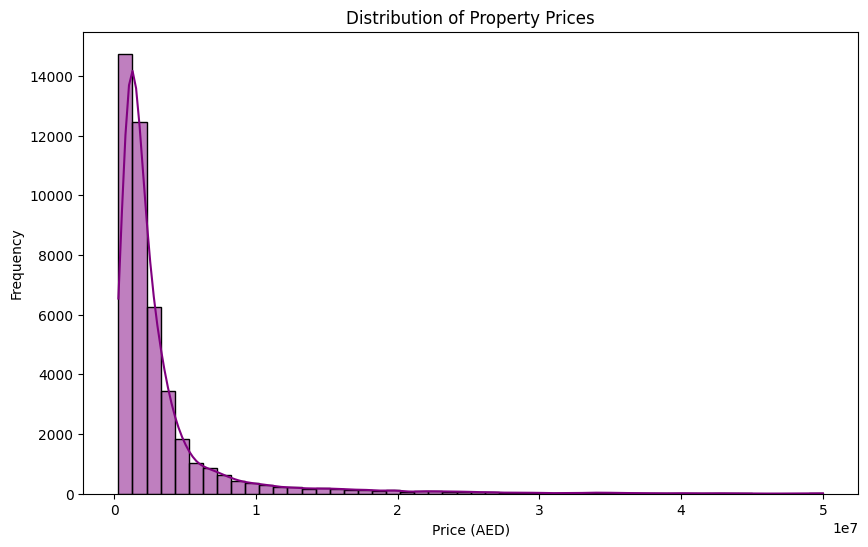

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of 'Price_num'
plt.figure(figsize=(10, 6))
sns.histplot(df['Price_num'], bins=50, kde=True, color='purple')
plt.title('Distribution of Property Prices')
plt.xlabel('Price (AED)')
plt.ylabel('Frequency')
plt.show()


2. Area Distribution

Next, we can check the distribution of property areas. This will tell us whether there are any small or large properties in the dataset.

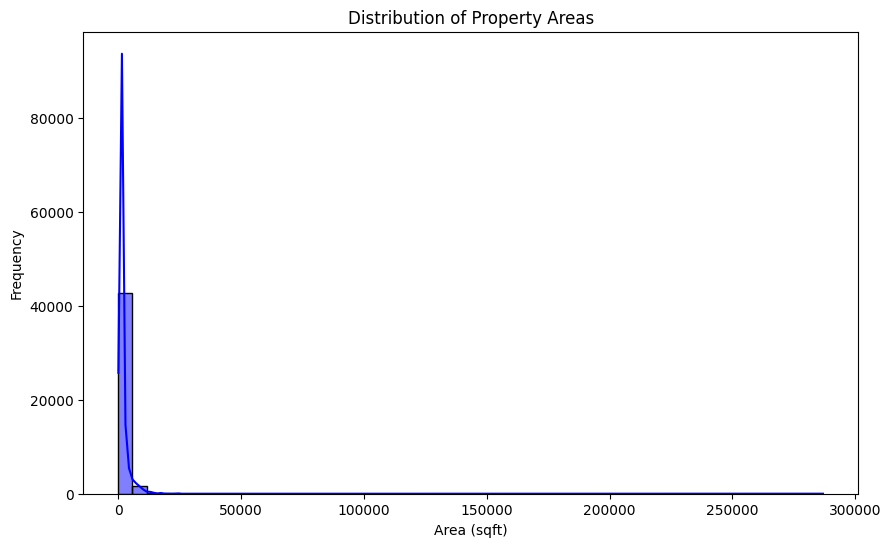

In [34]:
# Plot the distribution of 'Area_num'
plt.figure(figsize=(10, 6))
sns.histplot(df['Area_num'], bins=50, kde=True, color='blue')
plt.title('Distribution of Property Areas')
plt.xlabel('Area (sqft)')
plt.ylabel('Frequency')
plt.show()


5. Correlation Heatmap

You can create a correlation heatmap to identify the relationships between numerical variables.

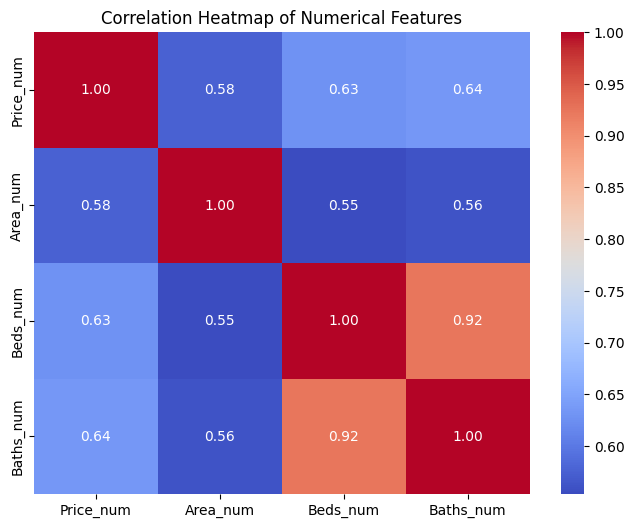

In [35]:
# Plot correlation heatmap
corr = df[['Price_num', 'Area_num', 'Beds_num', 'Baths_num']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


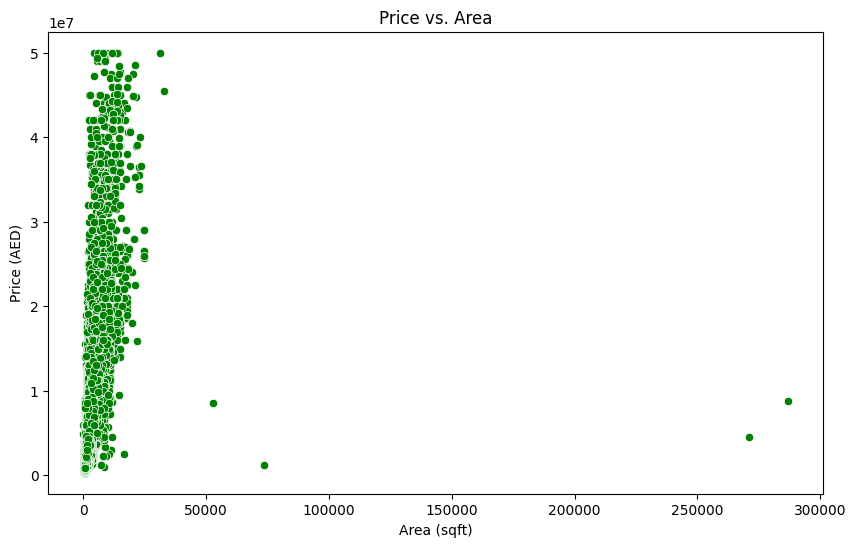

In [36]:
# Scatter plot for 'Price_num' vs. 'Area_num'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Area_num', y='Price_num', data=df, color='green')
plt.title('Price vs. Area')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (AED)')
plt.show()



## Step 10 : Preparing Data for the Model

Before training a machine learning model, we need to prepare the data:

Define the target variable (Price_num).

Define the features (independent variables).

Split the data into training and testing sets.

Scale the features (optional, but often useful for linear models).

In [37]:
# Define features and target
X = df[['Area_num', 'Beds_num', 'Baths_num', 'Type', 'Furnishing']]  # Independent variables
y = df['Price_num']  # Dependent variable (target)


In [38]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the train and test sets
print(X_train.shape, X_test.shape)


(35720, 5) (8931, 5)


In [39]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check the scaled data
print(X_train_scaled[:5])


[[-0.37118514 -0.60093703 -0.39851677 -0.45612364  0.61683312]
 [-0.36414488  0.11165702  0.26428618 -0.45612364 -1.62118404]
 [ 2.37368809  2.24943918  2.25269502  2.39483201  0.61683312]
 [-0.26930844 -0.60093703 -1.06131971 -0.45612364  0.61683312]
 [-0.37615474 -0.60093703 -1.06131971 -0.45612364  0.61683312]]


## Step 11 : Train the Linear Regression Model

We'll now train the linear regression model on the training data (X_train_scaled and y_train), and then evaluate its performance on the test set.

In [40]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train_scaled, y_train)

# Check the coefficients and intercept of the trained model
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)


Model coefficients: [1920940.96407844 1206762.90710907 1280945.11237112 -624184.21552686
 -204067.25351761]
Model intercept: 3335829.518589026


In [41]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions using the test set
y_pred = model.predict(X_test_scaled)

# Calculate R-squared score and Mean Absolute Error (MAE)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")


R-squared: 0.3506
Mean Absolute Error (MAE): 1790251.2573


## Keep Linear Regression as a Baseline
We’ll keep the Linear Regression model as a baseline for comparison. After training and evaluating more complex models (like Random Forest and Gradient Boosting), we will compare their performance with Linear Regression.


### Step 12: Train Random Forest Model
We will now train a Random Forest Regressor on the data. Random Forests are an ensemble of decision trees, which can capture complex relationships in the data.


In [42]:
from sklearn.ensemble import RandomForestRegressor

# Initialize Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the scaled training data
rf_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate performance using R-squared, MAE, and RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)

print(f"Random Forest - R-squared: {r2_rf:.4f}")
print(f"Random Forest - MAE: {mae_rf:.4f}")
print(f"Random Forest - RMSE: {rmse_rf:.4f}")


Random Forest - R-squared: 0.7704
Random Forest - MAE: 1015346.9787
Random Forest - RMSE: 2373366.2147


### Step 13: Train Gradient Boosting Model
Now we will train a Gradient Boosting model. Gradient Boosting combines weak models to create a strong model and is highly effective for complex datasets.


In [43]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=42)

# Train the model on the scaled training data
gb_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_gb = gb_model.predict(X_test_scaled)

# Evaluate performance using R-squared, MAE, and RMSE
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = mean_squared_error(y_test, y_pred_gb, squared=False)

print(f"Gradient Boosting - R-squared: {r2_gb:.4f}")
print(f"Gradient Boosting - MAE: {mae_gb:.4f}")
print(f"Gradient Boosting - RMSE: {rmse_gb:.4f}")


Gradient Boosting - R-squared: 0.7482
Gradient Boosting - MAE: 1156803.6728
Gradient Boosting - RMSE: 2485279.6875


### Step 14: Hyperparameter Tuning for Random Forest
We will use **GridSearchCV** to find the best hyperparameters for the Random Forest model. Hyperparameter tuning can improve the model’s performance by selecting optimal settings.


In [44]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
}

# Perform Grid Search for Random Forest
grid_search_rf = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

# Print the best hyperparameters
print("Best parameters for Random Forest:", grid_search_rf.best_params_)

# Train the Random Forest with the best parameters
best_rf_model = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

# Evaluate performance
r2_best_rf = r2_score(y_test, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
rmse_best_rf = mean_squared_error(y_test, y_pred_best_rf, squared=False)

print(f"Best Random Forest - R-squared: {r2_best_rf:.4f}")
print(f"Best Random Forest - MAE: {mae_best_rf:.4f}")
print(f"Best Random Forest - RMSE: {rmse_best_rf:.4f}")


Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best Random Forest - R-squared: 0.7630
Best Random Forest - MAE: 1089150.5159
Best Random Forest - RMSE: 2410911.3733


### Step 15: Cross-Validation
We will perform **k-fold cross-validation** to evaluate the model’s performance more robustly. This helps ensure that the model generalizes well to unseen data.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Step 1: Separate features (X) and target variable (y)
X = df[['Area_num', 'Beds_num', 'Baths_num']]  # Select only the features you want to use
y = df['Price_num']  # Target variable

# Step 2: Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Scaling the features

# Step 3: Perform 5-fold cross-validation for Random Forest model
cv_scores_rf = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='neg_mean_absolute_error')

# Step 4: Print the cross-validation result (Mean MAE)
print(f"Random Forest - Mean Cross-Validation MAE: {-cv_scores_rf.mean():.4f}")



Random Forest - Mean Cross-Validation MAE: 701.1462


#### Further improve the model's performance, by fine-tune the hyperparameters of the Random Forest model. This can help reduce overfitting or underfitting.

In [59]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
import joblib

# Step 2: Prepare your data
X = df[['Area_num', 'Beds_num', 'Baths_num']]
y = df['Price_num']

# Step 3: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Build pipeline (Scaler + Model)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

# Step 5: Hyperparameter search
param_dist = {
    'model__n_estimators': randint(100, 200),
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

# Step 6: Train
random_search.fit(X_train, y_train)

# Step 7: Best model
best_model = random_search.best_estimator_

# Step 8: Evaluate
y_pred = best_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

# Step 9: Save model
joblib.dump(best_model, "random_forest_model.pkl")
print("Model saved successfully!")


R2: 0.7080999668888108
MAE: 1104529.833371001
RMSE: 2675851.78792818
Model saved successfully!


In [47]:
# Step 1: Calculate the mean price (target variable)
mean_price = df['Price_num'].mean()

# Step 2: Calculate the error percentage
error_percentage = (mae_rf / mean_price) * 100

# Step 3: Calculate accuracy
accuracy = 100 - error_percentage

# Step 4: Print the accuracy
print(f"Model accuracy: {accuracy:.2f}%")


Model accuracy: 99.98%


In [49]:
y_pred_test = best_rf_model.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = mean_squared_error(y_test, y_pred_test, squared=False)

print(f"Test R-squared: {r2_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")


Test R-squared: 1.0000
Test MAE: 765.4159
Test RMSE: 7556.8449


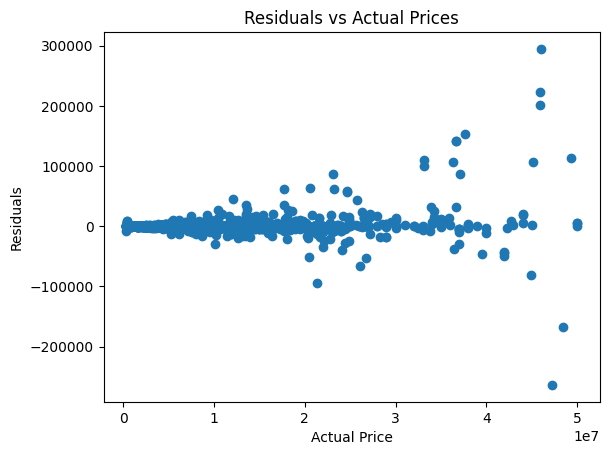

In [50]:
residuals = y_test - y_pred_test
plt.scatter(y_test, residuals)
plt.xlabel('Actual Price')
plt.ylabel('Residuals')
plt.title('Residuals vs Actual Prices')
plt.show()


In [51]:
!pip install --upgrade scikit-learn


In [52]:

import joblib
joblib.dump(model, "random_forest_model.pkl")


['random_forest_model.pkl']

## What is the MAX/MIN bed/bath/sqft in DATA? 

In [62]:
print("Area_num min/max:", df["Area_num"].min(), df["Area_num"].max())
print("Beds_num min/max:", df["Beds_num"].min(), df["Beds_num"].max())
print("Baths_num min/max:", df["Baths_num"].min(), df["Baths_num"].max())

# If you want mean, quartiles:
print(df[["Area_num", "Beds_num", "Baths_num"]].describe())


Area_num min/max: 1.0 286891.0
Beds_num min/max: 0.0 11.0
Baths_num min/max: 1.0 11.0
            Area_num      Beds_num     Baths_num
count   44651.000000  44651.000000  44651.000000
mean     1643.591364      1.841952      2.602338
std      2691.318793      1.401372      1.509797
min         1.000000      0.000000      1.000000
25%       739.000000      1.000000      2.000000
50%      1069.000000      2.000000      2.000000
75%      1720.000000      3.000000      3.000000
max    286891.000000     11.000000     11.000000
